<a href="https://colab.research.google.com/github/BhavyaKansal20/DeepLearning/blob/main/Telco_Churn_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0


## 2. Load Data


In [ ]:
DATA_PATH = "/content/Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.isna().sum()[df.isna().sum() > 0]


,0
Churn Reason,5174


## 3. Data Cleaning


In [ ]:
drop_cols = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code", "Lat Long",
    "Latitude", "Longitude", "Churn Label", "Churn Score", "Churn Reason"
]
df = df.drop(columns=drop_cols)

df["Total Charges"] = df["Total Charges"].replace(" ", np.nan).astype(float)
df["Total Charges"] = df["Total Charges"].fillna(0)

print("New shape:", df.shape)
df.head()


New shape: (7043, 21)


/tmp/ipykernel_5693/3820152350.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Total Charges"] = df["Total Charges"].replace(" ", np.nan).astype(float)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


## 4. Exploratory Data Analysis (EDA)

Churn Value
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_5693/3173121083.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn Value", data=df, palette=["#2E86AB", "#E63946"])


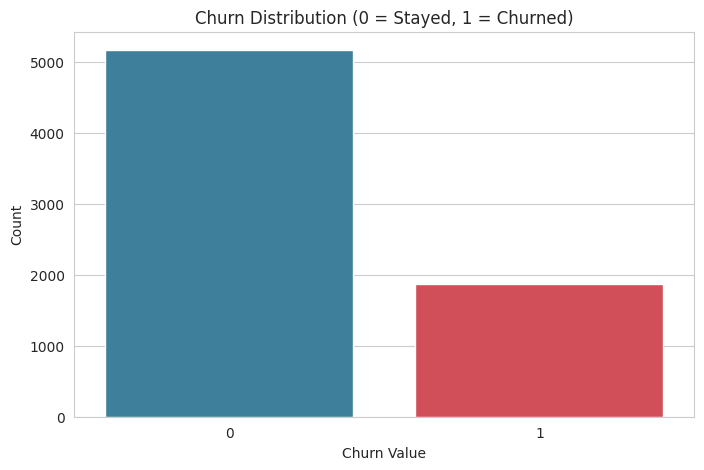

Overall churn rate: 26.54%


In [ ]:
target_counts = df["Churn Value"].value_counts()
print(target_counts)

plt.figure()
sns.countplot(x="Churn Value", data=df, palette=["#2E86AB", "#E63946"])
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.xlabel("Churn Value")
plt.ylabel("Count")
plt.show()

churn_rate = target_counts[1] / target_counts.sum() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")


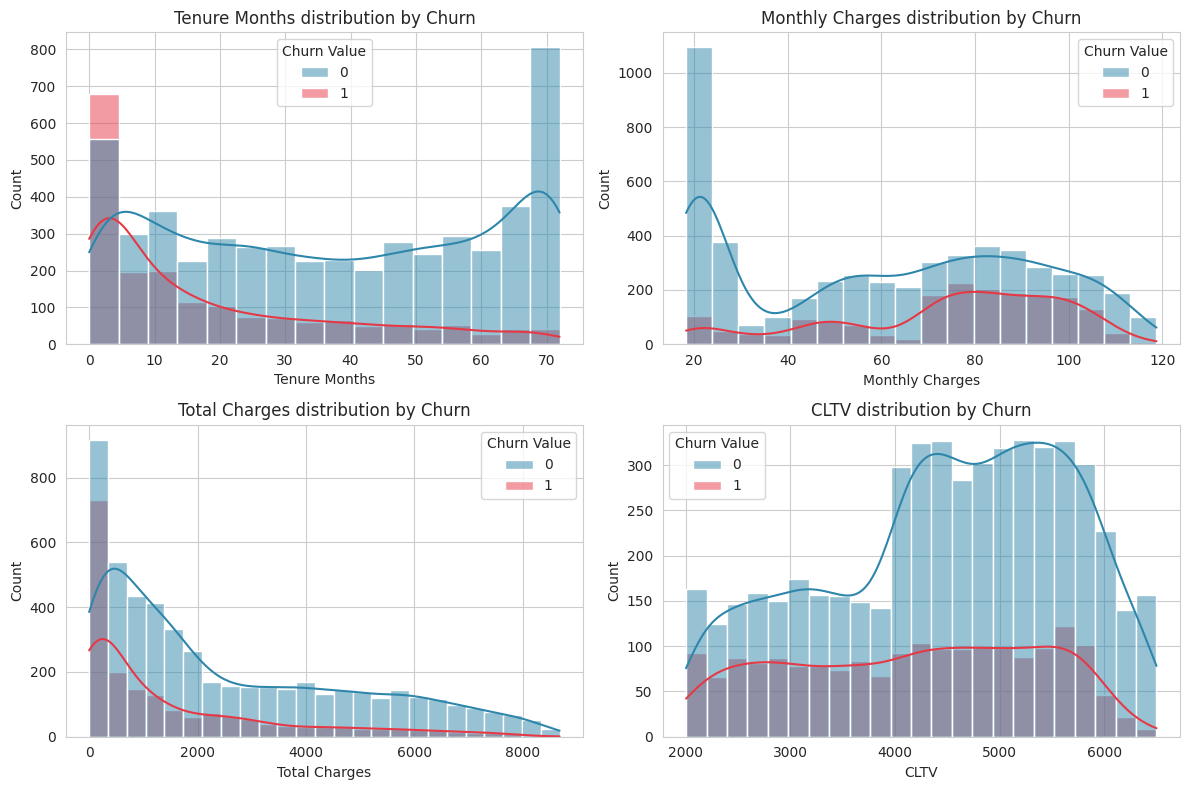

In [ ]:
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn Value", kde=True, ax=ax, palette=["#2E86AB", "#E63946"])
    ax.set_title(f"{col} distribution by Churn")
plt.tight_layout()
plt.show()


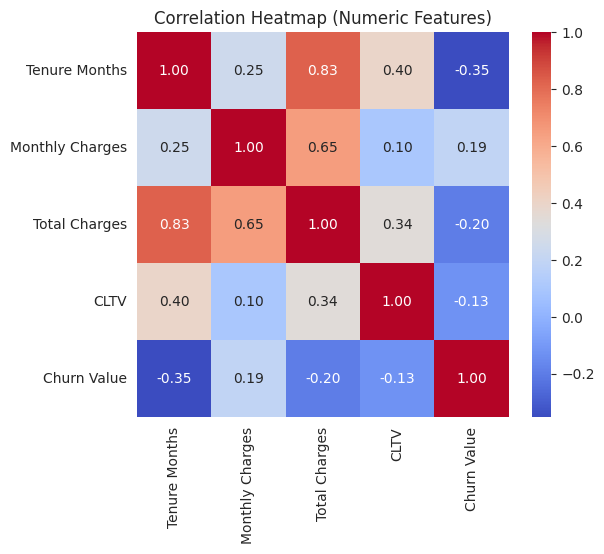

In [ ]:
plt.figure(figsize=(6, 5))
corr = df[numeric_cols + ["Churn Value"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


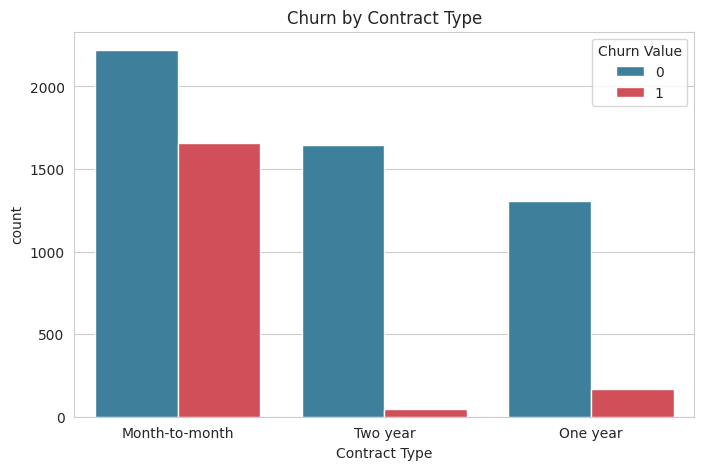

In [ ]:
plt.figure()
sns.countplot(x="Contract", hue="Churn Value", data=df, palette=["#2E86AB", "#E63946"])
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.show()


## 5. Feature Encoding & Scaling

In [ ]:
y = df["Churn Value"]
X = df.drop(columns=["Churn Value"])

cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded = X_encoded.astype("float32")

print("Final feature count:", X_encoded.shape[1])
X_encoded.head()


Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Final feature count: 31


,Tenure Months,Monthly Charges,Total Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2.0,53.849998,108.150002,3239.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2.0,70.699997,151.649994,2701.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,8.0,99.650002,820.500000,5372.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,28.0,104.800003,3046.050049,5003.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,49.0,103.699997,5036.299805,5340.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (5634, 31)
Test shape: (1409, 31)


In [ ]:
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight)


Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


## 6. Build the Deep Neural Network

**Architecture:**
```
Input(n_features)
  -> Dense(64, relu) -> BatchNorm -> Dropout(0.3)
  -> Dense(32, relu) -> BatchNorm -> Dropout(0.2)
  -> Dense(16, relu)
  -> Dense(1, sigmoid)   # binary classification output
```

In [ ]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

model = build_model(X_train_scaled.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 192 (768.00 B)

## 7. Train the Model

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6911 - auc: 0.7541 - loss: 0.5989 - val_accuracy: 0.6868 - val_auc: 0.8083 - val_loss: 0.5683 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7364 - auc: 0.8187 - loss: 0.5233 - val_accuracy: 0.7072 - val_auc: 0.8241 - val_loss: 0.5414 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7406 - auc: 0.8340 - loss: 0.5032 - val_accuracy: 0.7169 - val_auc: 0.8281 - val_loss: 0.5357 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7531 - auc: 0.8438 - loss: 0.4868 - val_accuracy: 0.7258 - val_auc: 0.8329 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7621 - auc: 0.8504 - loss: 0.4773 - val_accuracy: 0.7276 - val_auc: 0.8373 - val_loss: 0.5290 - learning_rate: 0.0010
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7657 - a

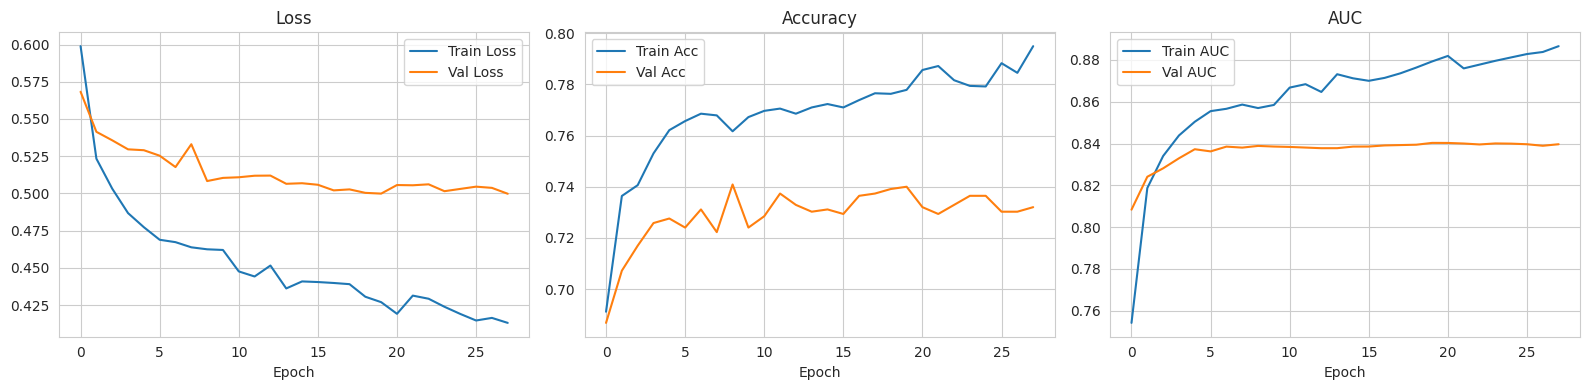

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(history.history["auc"], label="Train AUC")
axes[2].plot(history.history["val_auc"], label="Val AUC")
axes[2].set_title("AUC"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.show()


## 8. Evaluate on Test Set

In [ ]:
y_pred_proba = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC-AUC: {test_auc:.4f}")


Classification Report:

              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

Test ROC-AUC: 0.8459


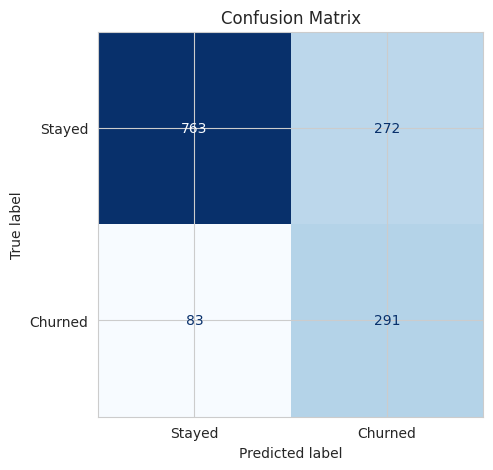

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()


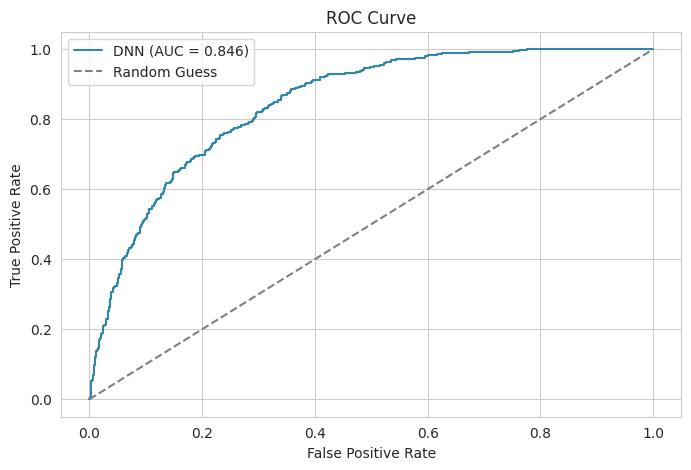

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"DNN (AUC = {test_auc:.3f})", color="#2E86AB")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 9. Save the Model



In [ ]:
model.save("telco_churn_dnn_model.keras")
print("Model saved as telco_churn_dnn_model.keras")


Model saved as telco_churn_dnn_model.keras


In [ ]:
sample = X_test_scaled[0:1]
sample_true_label = y_test.iloc[0]

pred_prob = model.predict(sample, verbose=0)[0][0]
print(f"Actual label: {sample_true_label}")
print(f"Predicted churn probability: {pred_prob:.4f}")
print(f"Predicted label: {'Churn' if pred_prob >= 0.5 else 'No Churn'}")


Actual label: 0
Predicted churn probability: 0.1422
Predicted label: No Churn
